In [1]:
from loguru import logger
logger.remove()
import sys
logger.add(sys.stderr, level="INFO")

import numpy as np
import pandas as pd
import xarray as xr
import torch
from pathlib import Path
import itertools

from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(
    context="paper",
    style="ticks",
    palette="Set2",
    rc={
        "figure.dpi": 600, "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "figure.labelsize": "small",
    },
)

from lib.models import DJModel
from lib.computation.statistics import cluster_correction
from lib.datasets import load_n_subjects, load_target_var, load_dataset
from lib.analyses.loaders import load_significant_times
from lib.analyses._plots import _plot_generalization, _plot_eigenspectrum
from bonner.caching import BONNER_CACHING_HOME
from bonner.computation.decomposition import PCA
from bonner.computation.metrics import covariance, pearson_r
from lib.computation.statistics import compute_p
from bonner.datasets.hebart2022_things_behavior import load_embeddings
from lib.datasets.hebart2022_things_behavior import sort_embeddings
from bonner.datasets.gifford2022_things_eeg_2 import load_metadata

# Import helper functions for memory-efficient loading
from lib._notebook_helpers import (
    get_scorer_kwargs,
    spearman_brown_correction,
    load_cvpca_dimensionality_streaming,
    load_model_decoding_dimensionality_streaming,
    load_bhv_dimensionality_streaming,
    add_time_markers,
    plot_with_sem,
)

In [2]:
# Common configuration
n_permutations = 1000
model_uid = "openclip_rn50_yfcc15m"


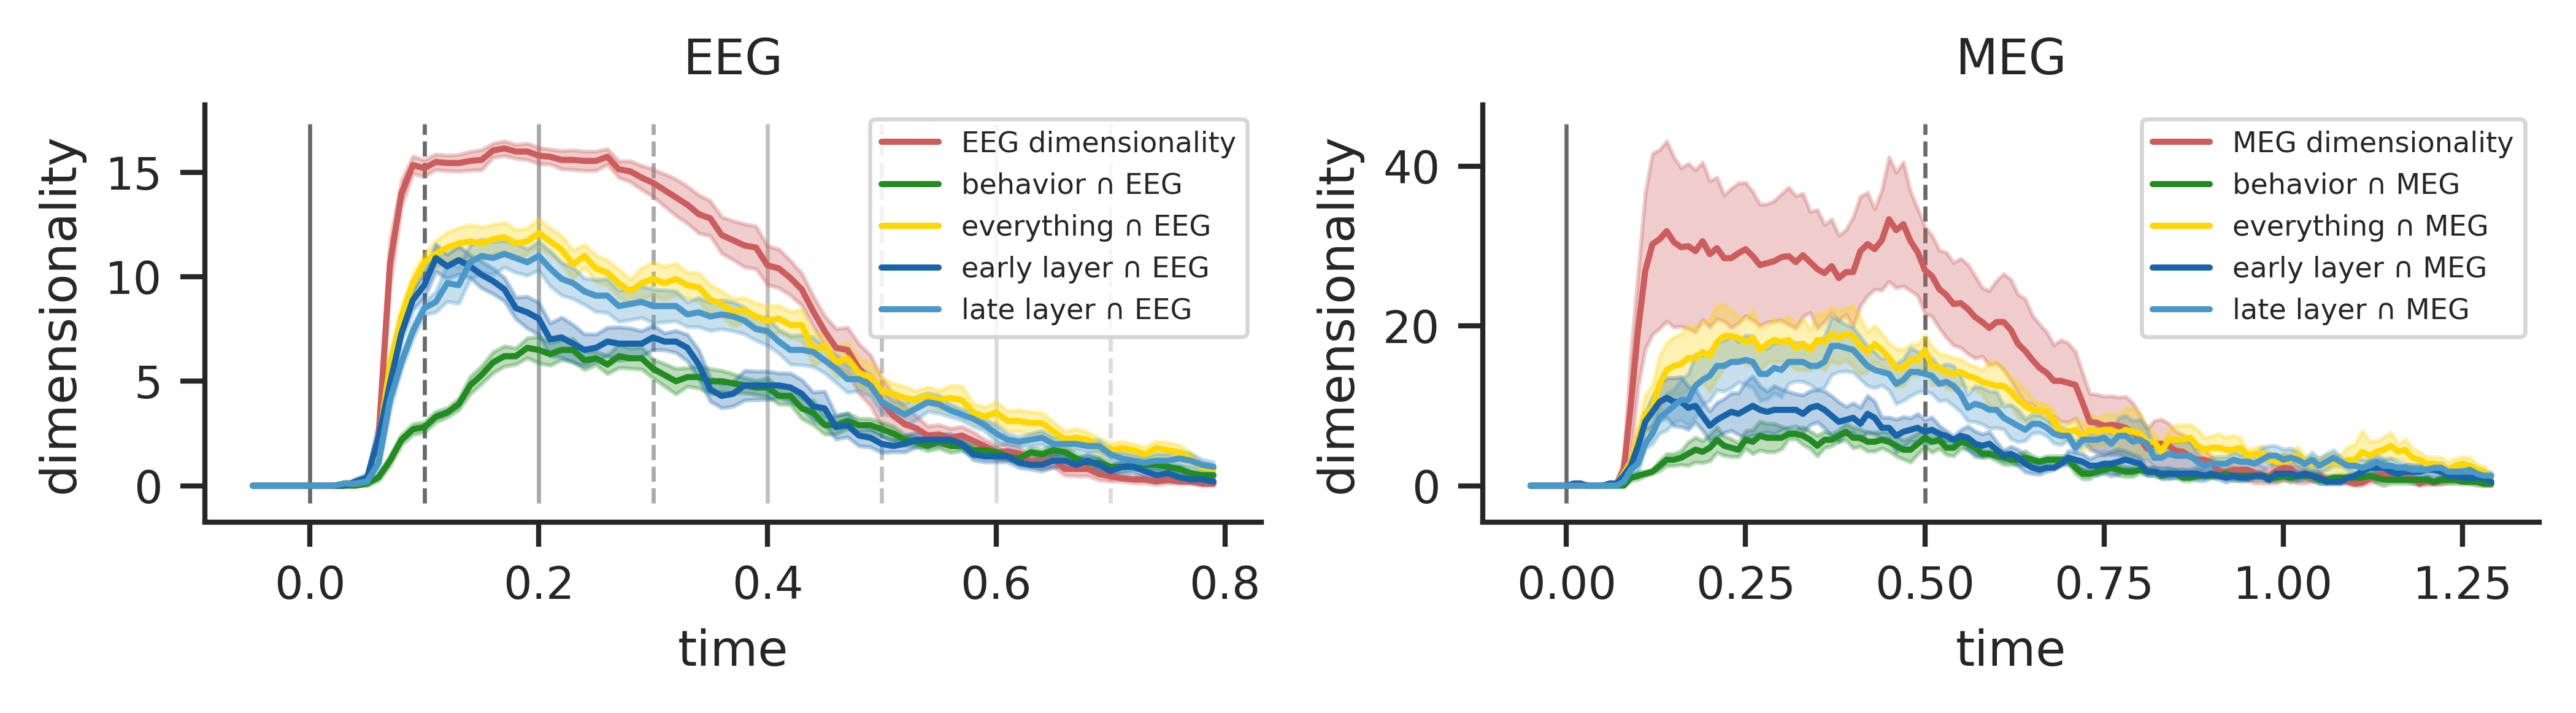

In [3]:
plt.close()
width_mm = 180
width_inches = width_mm / 25.4
height_inches = width_inches / 3.5
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, figsize=(width_inches, height_inches))

dataset = "things_eeg_2"
subjects = "all"
list_dim = "time"
folds = False
decoding_str = ".subset=False.pca=False"
load_dataset_kwargs = "default"

########## EEG dimensionality ##########
ax = axs[0]
ax.set_title("EEG")

# Load CV-PCA dimensionality
cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "EEG" if dataset == "things_eeg_2" else "MEG", time_min=-0.05)

# Load model decoding dimensionality (4-node model)
model_name = "plssvd"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)
model_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto")
ndf = load_model_decoding_dimensionality_streaming(model_subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds)

# Load behavior decoding dimensionality
bhv_scorer_kwargs, bhv_target_var = get_scorer_kwargs(model_name)
bhv_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={bhv_scorer_kwargs}")
bhv_ndf = load_bhv_dimensionality_streaming(bhv_subpath, dataset, n_permutations, bhv_target_var, time_min=-0.05, folds=folds)

# Load everything decoding dimensionality
e_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/everythingz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto")
endf = load_bhv_dimensionality_streaming(e_subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds)

# Plot CV-PCA dimensionality
label = "EEG dimensionality" if dataset == "things_eeg_2" else "MEG dimensionality"
sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax, label=label, color="indianred", errorbar=None)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax.fill_between(cdf.time.unique(), score-err, score+err, color="indianred", alpha=0.3)

# Plot behavior dimensionality
label = "behavior \u2229 EEG" if dataset == "things_eeg_2" else "behavior \u2229 MEG"
sns.lineplot(data=bhv_ndf, x="time", y="n_pc", ax=ax, color="forestgreen", label=label, errorbar=None)
score = bhv_ndf.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
err = bhv_ndf.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
ax.fill_between(bhv_ndf.time.unique(), score-err, score+err, color="forestgreen", alpha=0.3)

# Plot everything dimensionality
label = "everything \u2229 EEG" if dataset == "things_eeg_2" else "everything \u2229 MEG"
sns.lineplot(data=endf, x="time", y="n_pc", ax=ax, color="gold", label=label, errorbar=None)
score = endf.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
err = endf.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
ax.fill_between(endf.time.unique(), score-err, score+err, color="gold", alpha=0.3)

# Plot model layer dimensionality
sns.lineplot(data=ndf, x="time", y="n_pc", ax=ax, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)
for i, node_name in enumerate(ndf["node"].unique()):
    node_data = ndf[ndf["node"] == node_name]
    color = sns.color_palette("Blues_r", n_colors=4)[i]
    score = node_data.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
    ax.fill_between(node_data.time.unique(), score-err, score+err, color=color, alpha=0.3)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)

handles, labels = ax.get_legend_handles_labels()
handles = handles[:5]
labels = [*labels[:3], f"early layer \u2229 {'EEG' if dataset == 'things_eeg_2' else 'MEG'}", f"late layer \u2229 {'EEG' if dataset == 'things_eeg_2' else 'MEG'}"]
ax.get_legend().remove()
ax.legend(handles, labels, loc='upper right', fontsize='xx-small')
plt.tight_layout()
ax.set(ylabel="dimensionality")
eeg_xlim = ax.get_xlim()

########## MEG dimensionality ##########
ax = axs[1]
ax.set_title("MEG")
dataset = "things_meg"
load_dataset_kwargs = "from_raw=1.downsample_freq=100.h_freq=100.baseline=(None, 0).rois=op"

# Load CV-PCA dimensionality
cvpca_path = f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/tt_pca/analysis=behavior/space=eeg.pc_dims=target_var_neuroid.generalization_dim=time.split_dim=presentation.n_splits=2/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs=model_name=linear.l2_penalty=0.01/results.nc"
cdf = load_cvpca_dimensionality_streaming(cvpca_path, "EEG" if dataset == "things_eeg_2" else "MEG", time_min=-0.05)

# Load model decoding dimensionality
model_name = "plssvd"
scorer_kwargs, target_var = get_scorer_kwargs(model_name)
model_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/model_srpz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto")
ndf = load_model_decoding_dimensionality_streaming(model_subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds)

# Load behavior decoding dimensionality
bhv_scorer_kwargs, bhv_target_var = get_scorer_kwargs(model_name)
bhv_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/behaviorz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={bhv_scorer_kwargs}")
bhv_ndf = load_bhv_dimensionality_streaming(bhv_subpath, dataset, n_permutations, bhv_target_var, time_min=-0.05, folds=folds)

# Load everything decoding dimensionality
e_subpath = Path(f"/data/zchen160/cache/bonner-caching/temporal_dimensionality/main_analyses/everythingz_tt_decoding{decoding_str}/dataset={dataset}/load_dataset_kwargs={load_dataset_kwargs}/scorer_kwargs={scorer_kwargs}/model_kwargs=model_uid={model_uid}.n_components=auto")
endf = load_bhv_dimensionality_streaming(e_subpath, dataset, n_permutations, target_var, time_min=-0.05, folds=folds)

# Plot CV-PCA dimensionality
label = "EEG dimensionality" if dataset == "things_eeg_2" else "MEG dimensionality"
sns.lineplot(data=cdf, x="time", y="cvnsr", ax=ax, label=label, color="indianred", errorbar=None)
score = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").mean().values
err = cdf.groupby(["time", "subject"]).cvnsr.mean().groupby("time").sem().values
ax.fill_between(cdf.time.unique(), score-err, score+err, color="indianred", alpha=0.3)

# Plot behavior dimensionality
label = "behavior \u2229 EEG" if dataset == "things_eeg_2" else "behavior \u2229 MEG"
sns.lineplot(data=bhv_ndf, x="time", y="n_pc", ax=ax, color="forestgreen", label=label, errorbar=None)
score = bhv_ndf.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
err = bhv_ndf.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
ax.fill_between(bhv_ndf.time.unique(), score-err, score+err, color="forestgreen", alpha=0.3)

# Plot everything dimensionality
label = "everything \u2229 EEG" if dataset == "things_eeg_2" else "everything \u2229 MEG"
sns.lineplot(data=endf, x="time", y="n_pc", ax=ax, color="gold", label=label, errorbar=None)
score = endf.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
err = endf.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
ax.fill_between(endf.time.unique(), score-err, score+err, color="gold", alpha=0.3)

# Plot model layer dimensionality
sns.lineplot(data=ndf, x="time", y="n_pc", ax=ax, palette=sns.color_palette("Blues_r", n_colors=4), hue="node", errorbar=None)
for i, node_name in enumerate(ndf["node"].unique()):
    node_data = ndf[ndf["node"] == node_name]
    color = sns.color_palette("Blues_r", n_colors=4)[i]
    score = node_data.groupby(["time", "subject"]).n_pc.mean().groupby("time").mean().values
    err = node_data.groupby(["time", "subject"]).n_pc.mean().groupby("time").sem().values
    ax.fill_between(node_data.time.unique(), score-err, score+err, color=color, alpha=0.3)

ymin, ymax = ax.get_ylim()
add_time_markers(ax, dataset, ymin, ymax)

handles, labels = ax.get_legend_handles_labels()
handles = handles[:5]
labels = [*labels[:3], f"early layer \u2229 {'EEG' if dataset == 'things_eeg_2' else 'MEG'}", f"late layer \u2229 {'EEG' if dataset == 'things_eeg_2' else 'MEG'}"]
ax.get_legend().remove()
ax.legend(handles, labels, loc='upper right', fontsize='xx-small')
plt.tight_layout()
ax.set(ylabel="dimensionality")
meg_xlim = ax.get_xlim()

sns.despine()